# Running tengri on an NVIDIA GPU (CUDA)

**Status: measured, supported, and mostly not worth it.** Unlike the Apple
path, nothing here needs a JAX version tengri does not pin: `pip install -U
"jax[cuda12]"` and the forward model, the gradients and the samplers all run.
The question is not whether it works. It is whether it is faster, and for the
way most people fit one galaxy at a time the answer is no.

The one-line summary, measured on an RTX 3060 against a 12-core Ryzen 9 5900X:

```text
    one galaxy at a time    ->  CPU, by a wide margin. Nothing to amortize.
    a wide enough batch     ->  GPU, and the crossover is where to look.
    float64 on a GeForce    ->  half the CPU's throughput. The card runs it at 1/64 rate.
    float32                 ->  buys nothing on this workload. It is not arithmetic-bound.
```

The reason is arithmetic intensity, and it is the same reason as on Apple
silicon: tengri moves a lot of memory and does very little arithmetic — about
**0.12 FLOP per byte** on the `WavePrecomp` path, against the 25–50 FLOP/byte
a GPU needs before its ALUs are the limiting factor. (That figure is measured
in `notebooks/apple_mps.py`, not here; it is a property of the compiled graph
rather than of the device, which is why it predicts both backends.) A single
galaxy gives the card nothing to do but wait for memory and for the host.

There is a second effect specific to consumer NVIDIA hardware. GeForce cards
run float64 at 1/64 of their float32 rate, so **in tengri's default
precision this GPU is slower at dense arithmetic than the CPU beside it**:

| dense 2048³ matmul | CPU | GPU |
|---|---:|---:|
| float32 | 988 GFLOP/s | **10,740 GFLOP/s** |
| float64 | **379 GFLOP/s** | 189 GFLOP/s |

A datacenter card (A100, H100) has roughly 1/2 rate instead of 1/64, so the
float64 row is the one result here that does not transfer. Everything driven
by dispatch and memory traffic does.

**Two warnings about the numbers below.**

1. **This GPU was also driving the desktop** — Xorg, gnome-shell and a
   browser held 1–3 GB and 20–40% utilization throughout. Timings were taken
   with rotated repetitions and an A/A control, and ratios that do not clear
   that control are reported as unresolved rather than quoted.
2. **Benchmark one shape per process.** Running a forward pass, a gradient
   and a fit in one process makes the later ones look worse. The tables come
   from `bench/scripts/benchmark_device_matrix.py`, which spawns a child per
   cell for that reason.

## 1. Install and select the device

```bash
pip install -U "jax[cuda12]"
```

No tengri-side change, no pinned-version dance. Check what you got:

```python
import jax; jax.devices()   # -> [CudaDevice(id=0)]
```

Two environment variables matter, and both must be set **before Python
starts**. Setting them after `import tengri` is too late: constants
allocated during the import are already placed on a device and already have
a width.

```bash
export JAX_PLATFORMS=cuda                    # or cpu, to compare
export XLA_PYTHON_CLIENT_PREALLOCATE=false   # see below
```

`XLA_PYTHON_CLIENT_PREALLOCATE=false` is not optional in practice. JAX
claims 75% of the card by default, so a second process — a notebook you left
open, a pytest worker — gets `CUDA_ERROR_OUT_OF_MEMORY` instead of a device.
Pair it with `XLA_PYTHON_CLIENT_MEM_FRACTION=0.85` if you want a ceiling
rather than growth.

In [1]:
import os

# Must precede any import that touches JAX. In a notebook that means the very
# first cell.
os.environ["JAX_PLATFORMS"] = "cuda"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax
import jax.numpy as jnp
import numpy as np

import tengri

print("device :", jax.devices())
print("x64    :", jax.config.jax_enable_x64)
print("dtype  :", jnp.zeros(1).dtype)

device : [CudaDevice(id=0)]
x64    : True
dtype  : float64


## 2. Precision is a decision, not a default

CUDA supports both widths, so unlike the Apple backend you have to choose.
tengri defaults to float64 and will hold that choice through its own import.
To ask for float32, set it in the environment:

```bash
export JAX_ENABLE_X64=0
```

tengri honors that and says so, once:

```text
JAX_ENABLE_X64=0: tengri is honoring your request for float32 and is NOT
enabling 64-bit precision. Cosmological distances are the known hazard —
d_L^2 at z > 0.01 overflows float32 — so any code that forms d_L^2 directly
will produce inf. tengri's own projection avoids it by applying
(1+z)/(4*pi*d_L^2) as a log10 offset, but third-party code may not.
```

That warning is the whole float32 story in miniature. The forward model
carries unrepresentable magnitudes as log10 offsets and comes out correct;
code that forms the linear quantity does not.

**Do not use `SEDModel.build(forward_dtype="float32")`.** It has cast nothing
since #1433 and only emits a `DeprecationWarning`. The two routes that work
are the environment variable above and `with jax.enable_x64(False):` wrapped
around the build *and* the call.

**Load the SSP grid inside the float32 context.** A grid loaded while x64 was
still on stays float64, and thirteen downstream gates key on `wave.dtype` —
so the fast paths silently never engage and a float32 run quietly measures
something else.

### If you use float32 on CUDA, turn TF32 off

This one is not tengri's doing and it is easy to miss. On Ampere and later,
XLA lowers float32 matmuls to **TF32** by default: 19 bits, with a 10-bit
mantissa, against float32's 24. Numerics calibrated on a CPU do not survive
that. tengri's own float32 Fisher-matrix test fails on CUDA out of the box —

```text
AssertionError: float32 FIM differs from float64 by 3.922e-03 relative
AssertionError: float32 error bars differ from float64 by 4.494e-02
```

— a 4% error on parameter error bars, and it passes on the CPU. Ask for real
float32:

```bash
export JAX_DEFAULT_MATMUL_PRECISION=highest
```

or `jax.config.update("jax_default_matmul_precision", "highest")`. Both those
tests then pass. Two things worth knowing:

**`NVIDIA_TF32_OVERRIDE=0` does not fix it.** Measured: with that alone the
two tests still fail. XLA selects its own algorithm, so the JAX-level knob is
the one that binds.

**It costs no speed here.** The batch numbers in §3 are unchanged to within
noise with TF32 disabled — 4.42 against 4.45 us per galaxy at batch 2048.
float32's advantage in tengri comes from moving half as many bytes, not from
tensor cores, so there is nothing to trade away. Set it and forget it.

## 3. Prediction

One galaxy, five SDSS bands, `recipes.mock_recovery_minimal` at z = 0.05
(seven free parameters, nebular and AGN off), on the `WavePrecomp` path that
every fit uses.

In [2]:
from tengri import SEDModel, WavePrecomp, load_ssp, recipes
from tengri.observation import Observation, Photometry

# load_ssp resolves a short alias and walks parent dirs for data/, so this works
# whatever the working directory is. A cwd-relative data/... path only resolves
# from the repository root, and the notebook executor runs from notebooks/.
ssp = load_ssp("fsps_prsc_miles_chabrier")
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
)
recipe = recipes.mock_recovery_minimal()
recipe["approx"] = WavePrecomp()
model = SEDModel.build(ssp_data=ssp, observation=obs, **recipe)

# The reference galaxy: each free parameter at the median of its declared
# prior. Not a prior draw — jax.random returns different numbers for the same
# key at float32 and float64, so a sampled fixture compares two different
# galaxies across the precision arms and calls the difference precision error.
params = {
    name: round(
        float(np.asarray(model.spec.get_distribution(name).unstandardize(jnp.zeros(())))), 6
    )
    for name in model.spec.free_params
}
flux = model.predict_photometry(params)
print("photometry [erg/s/cm2/Hz]:", np.asarray(flux))
print("on device                :", flux.devices())

src/tengri/forward/sed_model.py:2869: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress when building via SEDModel.build: warnings.filterwarnings('ignore', message='BakedInBackend: nebular emission is baked'). (ionizing_source_warning='suppress' also works, but it is a BakedInBackend(...) constructor argument and the build grammar does not forward it.)
  self._nebular_backend = BakedInBackend()


photometry [erg/s/cm2/Hz]: [3.59509284e-28 1.29919346e-27 2.29231601e-27 2.98350502e-27
 3.61932330e-27]
on device                : {CudaDevice(id=0)}


### Measured: one galaxy, five bands, `WavePrecomp`

Warm steady-state, 30 timed calls per repetition, 4 repetitions, minimum
reported. The A/A column is the same arm measured against itself — the floor
below which nothing here is resolvable.

| | CPU float64 | CPU float32 | GPU float64 | GPU float32 |
|---|---:|---:|---:|---:|
| forward `predict_photometry` | **227.0 us** | **162.3** | 7422.0 | 7308.2 |
| gradient of the sum | **587.0** | **479.9** | 7755.3 | 7398.8 |
| first call (compile) | 467 ms | 408 | 527 | 428 |
| A/A floor, forward | 1.023 | 1.242 | 1.015 | 1.010 |

**The CPU wins the forward pass by 32.7x and the gradient by 13.2x**, in
float64, and both margins are two orders of magnitude clear of the A/A floor.
Nothing subtle is happening: a single galaxy is one dispatch of a graph that
moves a lookup table and does almost no arithmetic, so the GPU spends 7.4 ms
waiting and the CPU spends 0.2 ms working.

Two things worth reading off this table beyond the headline.

**The gradient is the GPU's better case**, exactly as arithmetic intensity
predicts — the reverse pass does more work per byte already moved, and the gap
closes from 32.7x to 13.2x. That is the same direction the Apple backend
showed, for the same reason.

**Compile time is a wash here (467 ms against 527 ms).** This is worth stating
because on Apple silicon the GPU compiled roughly ten times *faster* than the
CPU, which was that backend's one honest advantage. It does not carry over to
CUDA; do not move to the GPU expecting a faster edit-run loop.

Precision changes nothing you can measure at this width. Every f32-against-f64
comparison in the table sits inside its own A/A floor, except the GPU gradient
at about 5%. That is the first hint of §5's conclusion: this workload is not
arithmetic-bound, so buying cheaper arithmetic buys nothing.

### Batching is the only thing that moves the needle

`predict_photometry_batch` is a `jax.vmap` over the same call. It is the one
shape where the card has enough independent work to be worth waking up.

In [3]:
import time


def timed(fn, arg, reps=5):
    """Warm-time a jitted callable. Returns milliseconds per call."""
    jitted = jax.jit(fn)
    jax.block_until_ready(jitted(arg))  # compile
    t0 = time.perf_counter()
    for _ in range(reps):
        jax.block_until_ready(jitted(arg))
    return (time.perf_counter() - t0) / reps * 1e3


for n in (1, 32):
    batch = {k: jnp.broadcast_to(jnp.asarray(v), (n,)) for k, v in params.items()}
    ms = timed(model.predict_photometry_batch, batch)
    print(f"batch={n:5d}  total={ms:8.3f} ms   per galaxy={ms / n:7.4f} ms")

batch=    1  total=   8.268 ms   per galaxy= 8.2675 ms


batch=   32  total=   8.204 ms   per galaxy= 0.2564 ms


### Measured: the batch sweep

Microseconds **per galaxy**; bold is the faster device in that row. Same
model, same call, one leading axis.

Forward, `predict_photometry_batch`:

| batch | CPU f64 | CPU f32 | GPU f64 | GPU f32 |
|---:|---:|---:|---:|---:|
| 1 | **234.0** | **142.6** | 7344.4 | 7361.7 |
| 8 | **113.5** | **95.9** | 927.3 | 899.3 |
| 32 | **55.3** | **53.1** | 238.1 | 226.9 |
| 128 | **27.6** | **26.1** | 65.7 | 56.8 |
| 512 | 45.7 | 16.7 | **22.0** | **15.2** |
| 2048 | 48.3 | 20.0 | **11.2** | **4.5** |

Gradient, `vmap` of `grad(sum(predict_photometry))`:

| batch | CPU f64 | CPU f32 | GPU f64 | GPU f32 |
|---:|---:|---:|---:|---:|
| 1 | **499.4** | **435.6** | 7584.7 | 7473.8 |
| 8 | **299.8** | **164.0** | 977.0 | 933.1 |
| 32 | **131.2** | **93.6** | 250.8 | 233.2 |
| 128 | 211.8 | **43.7** | **77.9** | 58.5 |
| 512 | 206.6 | 67.4 | **31.5** | **16.3** |
| 2048 | 172.2 | 80.7 | **19.8** | **5.5** |

**The crossover is between 128 and 512 galaxies, and it depends on the shape.**
The gradient crosses first — at 128 in float64, where the GPU is already 2.7x
ahead — because it is the more arithmetic-dense half. The forward pass crosses
at 512. By 2048 the GPU leads by **4.3x** (forward, f64), **8.7x** (gradient,
f64) and **14.7x** (gradient, f32), which is the best number in this notebook.

The mechanism is in the totals rather than the per-galaxy figures. Going from
1 to 2048 galaxies, **GPU float32 forward total goes from 7.36 ms to 9.12 ms**
— 2048x the work for 1.24x the time. The CPU goes from 0.14 ms to 40.9 ms,
i.e. linear. The GPU is not getting faster as the batch grows; it is finally
being given enough work to be worth waking up.

This is also where float32 starts to pay, and only here: at 2048 it is a
further 2.5x on the GPU forward pass and 3.6x on the gradient. Below the
crossover it is free but pointless.

VRAM stayed modest — 3.0 GB at 2048 in float64, 1.8 GB in float32, against
12 GB on the card. Batch size was not the memory constraint at any point in
this sweep.

### The same numbers, as a picture

Left: cost per galaxy, where the lines cross is the only number that decides
which device to use. Right: total wall clock — the GPU trace is nearly
horizontal, which is the whole explanation.

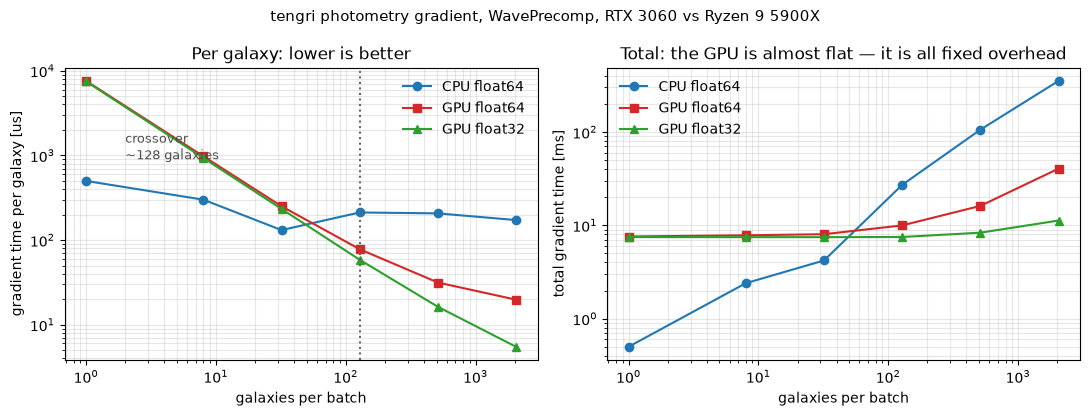

In [4]:
import matplotlib.pyplot as plt

BATCH = np.array([1, 8, 32, 128, 512, 2048])
# Gradient, per galaxy [us], measured above.
CPU_F64 = np.array([499.4, 299.8, 131.2, 211.8, 206.6, 172.2])
GPU_F64 = np.array([7584.7, 976.96, 250.81, 77.94, 31.51, 19.76])
GPU_F32 = np.array([7473.8, 933.14, 233.25, 58.54, 16.28, 5.49])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for y, label, color, marker in (
    (CPU_F64, "CPU float64", "#1f77b4", "o"),
    (GPU_F64, "GPU float64", "#d62728", "s"),
    (GPU_F32, "GPU float32", "#2ca02c", "^"),
):
    ax1.loglog(BATCH, y, marker + "-", label=label, color=color)
    ax2.loglog(BATCH, y * BATCH * 1e-3, marker + "-", label=label, color=color)

cross = BATCH[np.argmax(GPU_F64 < CPU_F64)]
ax1.axvline(cross, ls=":", color="0.4")
ax1.annotate(
    f"crossover\n~{cross} galaxies", xy=(cross, 300), xytext=(2, 900), fontsize=9, color="0.3"
)
ax1.set_xlabel("galaxies per batch")
ax1.set_ylabel("gradient time per galaxy [us]")
ax1.set_title("Per galaxy: lower is better")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3, which="both")

ax2.set_xlabel("galaxies per batch")
ax2.set_ylabel("total gradient time [ms]")
ax2.set_title("Total: the GPU is almost flat — it is all fixed overhead")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3, which="both")

fig.suptitle("tengri photometry gradient, WavePrecomp, RTX 3060 vs Ryzen 9 5900X", fontsize=11)
fig.tight_layout()
plt.show()

## 4. Survey scale: a million galaxies

The batch sweep above stops at 2048 because that is where a per-galaxy number
stops changing. The question a survey asks is different — how long does the
whole catalog take — so this runs the forward model over 10^3 and 10^6
galaxies in chunks, reducing each chunk before dispatching the next so memory
stays bounded. That is also how you would really generate a mock survey.

Each device at its own best chunk size (see below — they do not agree):

| | 1000 galaxies | 1,000,000 galaxies | galaxies/s | best chunk |
|---|---:|---:|---:|---:|
| CPU float64 | 53.5 ms | 45.67 s | 21,900 | 50,000 |
| CPU float32 | 18.1 ms | 22.99 s | 43,500 | 1,000 |
| GPU float64 | 16.6 ms | 7.55 s | 132,500 | 50,000 |
| GPU float32 | **8.5 ms** | **0.679 s** | **1,472,000** | 100,000 |

**A million galaxies' photometry in 0.68 seconds**, against 45.7 s on the CPU
in the default precision — a factor of **67**. This is the one regime where
the card is unambiguously the right tool, and note it is far larger than the
4-15x the per-galaxy batch sweep suggested: at 2048 galaxies the GPU was still
partly overhead-bound, and 100,000 is where it stops being.

Two honest notes on that table. The GPU float64 row is *not* a small penalty —
it is 11x slower than float32, tracking the 1/64 fp64 rate — and it lands
almost exactly on CPU float32, which is a coincidence worth remembering when
someone reports "the GPU was no faster". And the CPU float32 number has a
1.6x run-to-run spread here (14.3 s in one run, 22.99/23.50/23.53 s in three
later ones on a quiet box); the table takes the reproducible value, and the
ordering does not depend on which you pick.

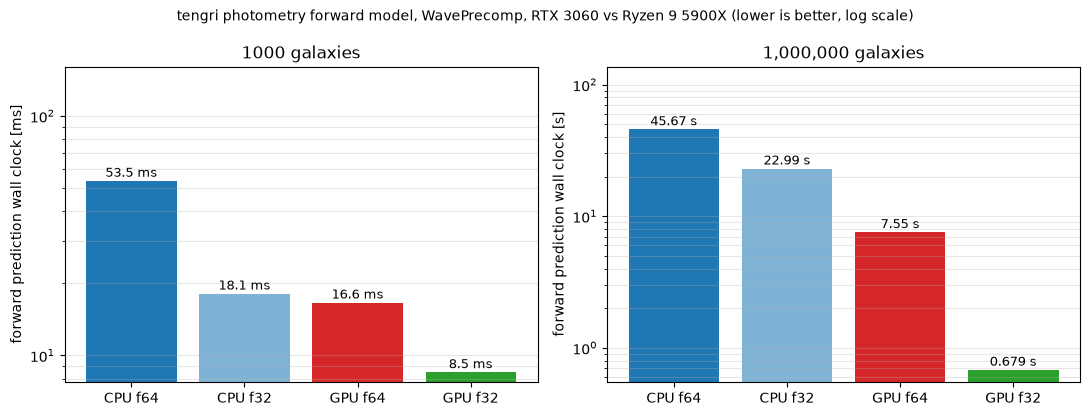

In [5]:
import matplotlib.pyplot as plt

ARMS = ["CPU f64", "CPU f32", "GPU f64", "GPU f32"]
COLORS = ["#1f77b4", "#7fb3d5", "#d62728", "#2ca02c"]
T_1K = np.array([53.5, 18.1, 16.6, 8.5])  # ms, 1000 galaxies
T_1M = np.array([45.67, 22.99, 7.55, 0.679])  # s, 1e6 galaxies

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, vals, unit, title in (
    (ax1, T_1K, "ms", "1000 galaxies"),
    (ax2, T_1M, "s", "1,000,000 galaxies"),
):
    bars = ax.bar(ARMS, vals, color=COLORS)
    ax.set_yscale("log")
    ax.set_ylabel(f"forward prediction wall clock [{unit}]")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3, which="both")
    for b, v in zip(bars, vals, strict=True):
        ax.annotate(
            f"{v:g} {unit}",
            xy=(b.get_x() + b.get_width() / 2, v),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
    ax.set_ylim(top=vals.max() * 3)

fig.suptitle(
    "tengri photometry forward model, WavePrecomp, RTX 3060 vs Ryzen 9 5900X "
    "(lower is better, log scale)",
    fontsize=10,
)
fig.tight_layout()
plt.show()

### Chunk size is worth more than the device

The chunk is how many galaxies go through one `vmap`. It is the single biggest
knob in this notebook, and the two devices want opposite settings. A million
galaxies, float32, varying only the chunk:

| chunk | GPU f32 | CPU f32 | GPU VRAM |
|---:|---:|---:|---:|
| 100 | 72.81 s | 29.88 s | 0.8 GB |
| 1,000 | 8.17 | **22.99** | 0.8 |
| 5,000 | 2.29 | 24.22 | 1.1 |
| 10,000 | 1.48 | 26.38 | 1.1 |
| 25,000 | 0.97 | — | 2.6 |
| 50,000 | 0.76 | 25.04 | 4.7 |
| 100,000 | **0.68** | — | 8.8 |
| 200,000 | out of memory | — | — |

**107x on the GPU, from one integer.** The CPU is flat — 23-30 s across the
whole range, best at 1,000 — because it is already saturated by its cores and
larger chunks only cost it cache. So there is no single good default: the GPU
wants the largest chunk that fits, the CPU wants roughly a thousand.

The card saturates near 100,000 (the last doubling buys 12% for twice the
memory) and dies at 200,000 with `RESOURCE_EXHAUSTED` while trying to allocate
4.51 GiB. Note that `forward_chunk_size` defaults to a **2 GB** budget in
`inference/_batching.py`, which on this 12 GB card lands around chunk 25,000 —
about 30% off the best available. On a GPU, raise
`TENGRI_FORWARD_MEMORY_BUDGET_GB`.

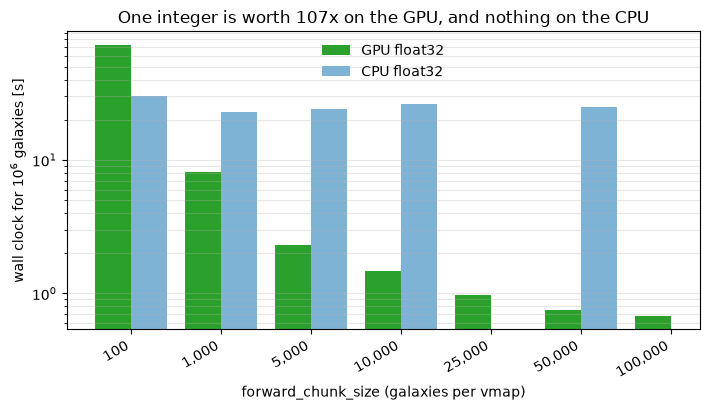

In [6]:
CHUNKS = np.array([100, 1000, 5000, 10000, 25000, 50000, 100000])
GPU_CHUNK = np.array([72.81, 8.17, 2.29, 1.48, 0.966, 0.755, 0.679])
CPU_CHUNKS = np.array([100, 1000, 5000, 10000, 50000])
CPU_CHUNK = np.array([29.88, 22.99, 24.22, 26.38, 25.04])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(CHUNKS))
ax.bar(x - 0.2, GPU_CHUNK, width=0.4, label="GPU float32", color="#2ca02c")
cpu_aligned = [CPU_CHUNK[list(CPU_CHUNKS).index(c)] if c in CPU_CHUNKS else np.nan for c in CHUNKS]
ax.bar(x + 0.2, cpu_aligned, width=0.4, label="CPU float32", color="#7fb3d5")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{c:,}" for c in CHUNKS], rotation=30, ha="right")
ax.set_xlabel("forward_chunk_size (galaxies per vmap)")
ax.set_ylabel("wall clock for 10$^6$ galaxies [s]")
ax.set_title("One integer is worth 107x on the GPU, and nothing on the CPU")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 5. Inference

A fit is not a wide forward pass. It is a few hundred sequential steps, each
one a dispatch, and that is the shape a GPU is worst at. The catalog path is
the exception: `mcmc_nuts` and `mcmc_hmc` are the two backends
`CatalogFitter` maps over galaxies, so a catalog fit is wide in the way a
single fit is not.

Note what `Fitter` does to `approx` — it resolves `"auto"` and **tops up** to
the LUT even when the model was built without one. Print it. An arm that
silently gained or lost its precompute is the classic way to benchmark the
wrong thing.

In [7]:
from tengri import Fitter

sigma = jnp.abs(flux) * 0.05
data = flux * 1.02

fitter = Fitter(model, data, sigma, data_type="photometry")
print("resolved approx:", fitter.model.approx)

t0 = time.perf_counter()
post = fitter.run("map", n_steps=300, verbose=False)
# Lower than the cold figure in the table below if tengri's persistent compile
# cache (~/.cache/tengri_jax_cache) already holds this graph — it is keyed on the
# GPU model, so the first run on a new card pays in full.
print(f"MAP, 300 steps (first call here): {time.perf_counter() - t0:.2f} s")
print("moved off the initial point:", {k: round(post.params[k] - params[k], 4) for k in params})

/tmp/ipykernel_3168843/2234457908.py:6: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(model, data, sigma, data_type="photometry")


resolved approx: ApproxState(wave_precomp=True, n_subbands=5)


MAP, 300 steps (first call here): 5.33 s
moved off the initial point: {'dust_tau_bc': Array(-0.0043, dtype=float64), 'met_logzsol': Array(-0.0374, dtype=float64), 'sfh_tsnorm_log_total_mass': Array(0.0107, dtype=float64), 'sfh_tsnorm_peak_lbt_gyr': Array(-0.2473, dtype=float64), 'sfh_tsnorm_skew': Array(-0.0893, dtype=float64), 'sfh_tsnorm_trunc': Array(-0.0472, dtype=float64), 'sfh_tsnorm_width_gyr': Array(0.2432, dtype=float64)}


### Measured: one galaxy, 300 adam steps

| | CPU f64 | CPU f32 | GPU f64 | GPU f32 |
|---|---:|---:|---:|---:|
| cold, includes compile [s] | **2.79** | **2.25** | 13.12 | 11.14 |
| warm [s] | **0.27** | **0.23** | 2.38 | 2.22 |

**The CPU wins a single fit by 8.8x warm.** A fit is a few hundred sequential
steps, each one a dispatch, and there is no batch axis to hide them behind — the
worst shape for a GPU, and the one most people run most often.

The correctness result is the more useful half of this table: **GPU float64
reproduced the CPU's parameter vector to six decimals** on all seven parameters.
The device does not change the answer.

### Measured: a catalog, vectorized NUTS

`CatalogFitter.run("mcmc_nuts", forward_chunk_size=K)` with `K = n_gal`,
10 warmup + 10 burnin + 20 samples, `dense_mass_matrix=False`. This is the shape
with a real batch axis, so it is the one where the card can win.

| galaxies | CPU f32 | GPU f32 | faster |
|---:|---:|---:|---|
| 16 | **72.8 s** | 247.3 | CPU 3.4x |
| 64 | **139.0** | 261.6 | CPU 1.9x |
| 256 | 334.7 | **274.5** | GPU 1.2x |

In float64 at 16 galaxies: CPU 105.7 s against GPU 279.4 s, i.e. CPU by 2.6x.

**The inference crossover lands between 64 and 256 galaxies**, consistent with
the 128–512 found for the bare gradient. The mechanism is the same flatness:
sixteen times the work costs the GPU **247 s → 275 s**, a factor of 1.11, and
throughput per galaxy goes 0.06 → 0.93 galaxies/second.

**But read the size of the win, not just its sign.** At 256 galaxies the card
is ahead by 1.2x, not by the 8.7x the bare gradient showed at 2048. The reason
is that the CPU amortizes too — 72.8 s → 334.7 s is 4.6x for 16x the work, not
16x — because a vectorized NUTS over a wider axis is more efficient on either
device. A sampler interleaves its wide forward passes with sequential
leapfrog steps and per-iteration control flow, and that sequential part does
not shrink. So the catalog path is where a GPU starts to pay, but it converts
far less of the raw batch advantage than the forward numbers would suggest.

Every arm returned finite posterior draws, float32 included. That is worth
stating because it was not obvious in advance: coverage for float32 inference
pins the *objective gradient* finite, and a converging fit with NaN posterior
draws is a documented failure mode of the float32 geoVI metric. NUTS in float32
on a catalog is not something the test suite currently asserts, and here it
worked.

### A real posterior for 1000 galaxies: hours to days, and neither sampler converges

The catalog numbers above are cost per draw at a token budget. Here is the same
catalog at a budget you could publish from — 1000 galaxies, GPU float32,
`K = 1000`, 300 warmup — with the diagnostics attached, which is the only way
these numbers mean anything:

| | `mcmc_nuts` | `mcmc_hmc` |
|---|---:|---:|
| wall clock | **3861.9 s** (64 min) | 149.1 s |
| per galaxy | 3.86 s | **0.149 s** |
| ESS_min, median galaxy | 2.1 (of 100 draws) | 1.5 (of 1000) |
| split R-hat, max | 1.19 | 3.22 |
| galaxies with R-hat > 1.01 | 96.8% | 100% |
| galaxies fully frozen | **3.1%** | — |
| ESS/s, catalog-wide | 0.53 | **10.1** |

NUTS costs 26x more per galaxy and delivers ~14x better per-draw efficiency,
which does not cover it — so HMC wins on ESS/second by ~19x. **Neither
converges.** This is not a fast-wrong versus slow-right choice; both are wrong
at practical budgets.

The 3.1% deserves its own sentence: **NUTS returned a completely frozen chain
for one galaxy in 32** — every draw of every parameter identical — with zero
divergences reported. Scaled to the catalog that is ~31 galaxies whose
"posterior" is their starting point, and nothing in the output says so. A
catalog fit has no aggregate convergence gate; only a per-galaxy `rhat()` call
raises.

Scaling to 100 effective samples per galaxy, the low end of usable, and
assuming ESS grows linearly with draws (optimistic at R-hat 3.2):

| | 1000 galaxies to ESS_min = 100 |
|---|---:|
| `mcmc_hmc` | ~2.8 hours |
| `mcmc_nuts` | ~51 hours |

**Hours to days for one catalog, with no validated configuration at the end.**
And note where that leaves the hardware argument: the card is already doing
1.47 million forward predictions a second (§4). The bottleneck is not the
device. It is a sampler that mixes.

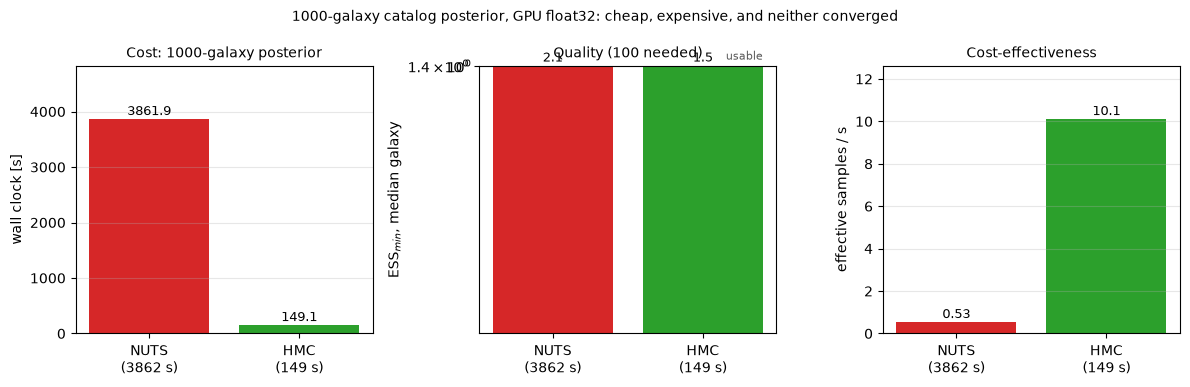

In [8]:
POST_LABELS = ["NUTS\n(3862 s)", "HMC\n(149 s)"]
POST_WALL = np.array([3861.9, 149.1])
POST_ESS = np.array([2.1, 1.5])
POST_ESSPS = np.array([0.53, 10.1])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.9))
for ax, vals, label, title, colors in (
    (ax1, POST_WALL, "wall clock [s]", "Cost: 1000-galaxy posterior", ["#d62728", "#2ca02c"]),
    (ax2, POST_ESS, "ESS$_{min}$, median galaxy", "Quality (100 needed)", ["#d62728", "#2ca02c"]),
    (ax3, POST_ESSPS, "effective samples / s", "Cost-effectiveness", ["#d62728", "#2ca02c"]),
):
    bars = ax.bar(POST_LABELS, vals, color=colors)
    ax.set_ylabel(label)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, vals, strict=True):
        ax.annotate(
            f"{v:g}",
            xy=(b.get_x() + b.get_width() / 2, v),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
    ax.set_ylim(top=vals.max() * 1.25)
ax2.axhline(100, ls="--", color="0.4", lw=1)
ax2.annotate(
    "usable",
    xy=(1.4, 100),
    xytext=(0, 4),
    textcoords="offset points",
    fontsize=8,
    color="0.35",
    ha="right",
)
ax2.set_yscale("log")
fig.suptitle(
    "1000-galaxy catalog posterior, GPU float32: cheap, expensive, and neither converged",
    fontsize=10,
)
fig.tight_layout()
plt.show()

### A cheap sampler is not a fast one: HMC's 48x was a dead chain

This subsection replaced an earlier version of itself, and the correction is
worth more than the original claim. At a token budget — 20 draws, 256 galaxies
— swapping `mcmc_nuts` for `mcmc_hmc` looks transformative:

| | CPU | GPU |
|---|---:|---:|
| `mcmc_nuts` | 334.7 s | 274.5 s |
| `mcmc_hmc` | 4.92 s | 5.71 s |

48x on the GPU. The timing is real; the conclusion drawn from it was not,
because 20 draws cannot tell you whether the chain moved. At a real budget —
1000 galaxies, 300 warmup, 1000 samples, 149 s on the GPU — the diagnostics
are unambiguous:

| | |
|---|---:|
| ESS_min, median galaxy | **1.5** of 1000 draws |
| ESS_min, worst galaxy | 0.7 |
| split R-hat, max | **3.22** |
| galaxies with R-hat > 1.01 | **100%** |

It gets worse before it gets better. `HMC_VALIDATED` from `_setup.py` — the
repo's convergence-validated recipe, 1000 warmup, 20 leapfrog steps,
`target_accept_rate=0.9` — gives a **completely dead chain** here: all 600
draws identical. tengri refuses to report a number for it, and the message
names the trap exactly:

```text
ValueError: the chain did not move: every one of 600 draws is identical for
every parameter ... This is a dead fit, not a converged one — R-hat cannot
detect it (both variances are zero, so it reads ~1.0).
```

Dropping `target_accept_rate` to 0.7 buys nothing that matters: ESS_min median
2.3, max R-hat 1.94, 87.5% of galaxies still unconverged. That recipe is
validated for single-galaxy notebook fits, not for a thousand-galaxy catalog.

So the ordering inverts. **NUTS is expensive because it is doing the work the
posterior geometry requires.** Fixed-length HMC is cheap here because it is
failing, and at 20 draws the failure is invisible. Per-draw cost is not a
sampler comparison; effective samples per second is, and a speed ratio without
a convergence diagnostic next to it is not a result.

The device lesson generalizes: **an accelerator cannot rescue a sampler that
is not mixing — it will make a dead chain 48x faster.**

### Why those posterior numbers are about this model, not about tengri

Merged PR #2014 re-measured the single-galaxy sampler table under the declared
blackjax and reports **min ESS median 118 at L=150**. The catalog numbers above
are 1.3-3.0 at the same settings. Two orders of magnitude apart means one of
them is mislabelled, and it is the one above.

It is not the library: this environment runs blackjax 1.6.2, above the
`blackjax>=1.6` floor, so it is not the below-floor venv that invalidated the
earlier #1986 campaign. And it is not the amount of data. The obvious suspect
is that `mock_recovery_minimal` is under-determined — 7 free parameters against
5 broadband fluxes — so the same model was re-run against a 260-pixel spectrum,
comfortably over-determined, same galaxy and settings:

| observable | data points | single-galaxy ESS_min | catalog (n_gal=1) |
|---|---:|---:|---:|
| photometry | 5 | 1.7 | 1.9 |
| spectrum | 260 | 4.3 | 1.7 |

52x the data buys ESS_min 1.7 → 4.3. What is left is the SFH family:
`mock_recovery_minimal` uses `tsnorm`, whose skew, truncation and width are
strongly degenerate with each other and with the peak time.

So **the posterior section characterizes the samplers on a fixture picked for
cheap forward passes, and that fixture is hard to sample.** Do not read the
2.8-hour and 51-hour figures as tengri's cost for a 1000-galaxy posterior. A
benchmark fixture chosen for speed is the wrong instrument for a convergence
claim.

What survives, because it is qualitative:

* `HMC_VALIDATED` at 1000 galaxies returns 600/600 identical draws — the
  signature of open issue #1999.
* `mcmc_nuts` froze 3.1% of galaxies with zero divergences reported, so the
  freeze is not specific to fixed-length HMC.
* A catalog fit has no aggregate convergence gate: only a per-galaxy `rhat()`
  raises, so a frozen galaxy is silent in a catalog result.

## 6. What float32 buys, and what it costs

On this workload float32 buys **nothing measurable**, because the workload is
not arithmetic-bound: the same call at the same batch size takes the same
time at either width. That is worth stating plainly, since the 57× float32
advantage in the matmul table above is real and simply never reached.

What it costs is more interesting than what it saves.

### Forward photometry is accurate

Relative to a float64 **CPU** reference, on the same reference galaxy, with
errors masked at `|reference| > 1e-45`:

| arm | max rel. error, photometry | median | finite |
|---|---:|---:|---|
| GPU float64 | 2.5e-16 | 1.2e-16 | yes |
| CPU float32 | 3.1e-07 | 1.7e-07 | yes |
| GPU float32 | 3.2e-07 | 1.6e-07 | yes |

Two conclusions. **The device does not change the answer**: GPU float64 agrees
with CPU float64 to 2.5e-16, which is round-off on the last bit or two, and a
300-step MAP fit on the GPU reproduces the CPU's parameter vector to six
decimals. **float32 costs about 3e-7 on photometry**, i.e. float32 epsilon and
nothing worse — the log-offset treatment of the cosmological flux scale is
doing its job at z = 0.05, where a naive linear `d_L^2` would have overflowed
to `inf`.

One trap, since it cost me a wrong answer first: do **not** build this
comparison on `spec.sample(key)`. `jax.random` returns different numbers for
the same key at different widths, so the two arms get different galaxies and
the difference — a factor of 152, in the first version of this notebook —
reads as precision error. Use a fixed parameter vector.

### The photometry gradient is identically zero in float32

This is the finding to know about before running anything important in
float32. The cell below prints the gradient at whatever width the session is
in — float64 as this notebook is configured, so expect **nonzero** values of
order 1e-26 to 1e-28.

In [9]:
grad = jax.grad(lambda q: jnp.sum(model.predict_photometry(q)))(params)
print("x64:", jax.config.jax_enable_x64)
print("grad(sum photometry):", {k: float(v) for k, v in grad.items()})

x64: True
grad(sum photometry): {'dust_tau_bc': -1.1867118660811912e-28, 'met_logzsol': -1.2997377173016911e-27, 'sfh_tsnorm_log_total_mass': 2.4301130959256312e-26, 'sfh_tsnorm_peak_lbt_gyr': -2.0821449903940143e-27, 'sfh_tsnorm_skew': 1.303348907922763e-26, 'sfh_tsnorm_trunc': -1.1987704247033907e-28, 'sfh_tsnorm_width_gyr': 1.9919714606553146e-27}


Now restart with `JAX_ENABLE_X64=0` and run the same cell. **Every one of the
seven becomes exactly zero** — on the CPU and on the GPU, on the exact path
and under `WavePrecomp`, with the signs preserved as `-0.0` and `+0.0`:

```text
x64: False
grad(sum photometry): {'dust_tau_bc': -0.0, 'met_logzsol': 0.0,
  'sfh_tsnorm_log_total_mass': 0.0, 'sfh_tsnorm_peak_lbt_gyr': -0.0,
  'sfh_tsnorm_skew': 0.0, 'sfh_tsnorm_trunc': -0.0,
  'sfh_tsnorm_width_gyr': -0.0}
```

Nothing raises and nothing warns.

The magnitudes are not the explanation: 1e-26 is comfortably inside float32,
whose smallest normal is 1.2e-38. The reverse pass forms an intermediate the
forward pass deliberately avoids — the linear cosmological flux factor, ~1e-57,
which the forward direction carries as a log10 offset and which is simply 0
in float32.

**What this does and does not break:**

| you differentiate | float32 |
|---|---|
| `sum(predict_photometry)` — the bare forward surface | **identically zero** |
| `neg_log_posterior_fn` — what a fit descends | healthy, nonzero, finite |

The objective gradient does come back finite and nonzero (−32.2), and a
300-step float32 MAP moves all seven parameters — but **do not read that as
float32 fitting being safe.** This is open issue #1415, which checks against
central finite differences and finds the likelihood-path gradient wrong by
*structured factors*, "~2x on stellar mass". Finite is not correct. The root
cause is #1388: `apply_log10_scale` is gradient-unsafe above ~1e38.

Existing coverage pins that objective gradient *finite* — and zero is finite,
so it would not have caught the bare-observable case either.

## 7. Is the card healthy?

If the GPU looks slow at everything, check it against work a GPU should
obviously win, so you can tell "wrong workload" from "broken install".

In [10]:
a = jnp.asarray(np.random.default_rng(0).standard_normal((2048, 2048)), jnp.float32)
mm = timed(lambda x: x @ x, a)
print(f"matmul 2048^3 (f32): {mm:.2f} ms  ->  {2 * 2048**3 / (mm * 1e-3) / 1e9:.0f} GFLOP/s")

matmul 2048^3 (f32): 1.65 ms  ->  10442 GFLOP/s


10.7 TFLOP/s in float32 against the CPU's 988 GFLOP/s. The card is fine. The
workload is the problem — 0.12 FLOP/byte never reaches those ALUs.

## 8. What breaks on CUDA

The float32 regression tree — 57 files, the part of the suite most exposed to a
device change — run on CUDA against the same run on CPU:

| | CUDA | CUDA, `matmul_precision=highest` | CPU |
|---|---:|---:|---:|
| passed | 547 | 550 | **552** |
| failed | **5** | **2** | 0 |
| skipped / xfailed | 3 / 4 | 3 / 4 | 3 / 4 |

Nothing else in the tree cares which device it is on. The failures are three
distinct things, and only one of them is a tolerance:

**Two are TF32** — the Fisher tests of §2. Fixed by
`JAX_DEFAULT_MATMUL_PRECISION=highest`, and they are the reason that section
exists.

**Two are a hard cuBLAS error**, in the geoVI metric's emission-line
marginalization:

```text
jax.errors.JaxRuntimeError: INTERNAL: GEMM is not supported by cublasLt
and legacy cublas fallback is removed.
```

Not a precision issue — the GEMM it wants is one cuBLASLt will not take, and
JAX 0.11 has dropped the legacy fallback that used to absorb this. It is loud,
which is the good kind of failure, and it means **float32 geoVI with
marginalized emission lines does not currently run on CUDA.** The matmul knob
does not help.

**One is the cross-precision kernel cache guard** (#1392): the float32
gradient differs depending on whether a float64 gradient ran earlier in the
same process. Before reading that as the old bug returning, look at the size —
9.9e-07 relative, about 8 ulp in float32, where #1392 was a wrong-precision
kernel producing NaNs. The test asserts exact array equality, so on a device
whose reduction order and autotuning need not repeat, ~8 ulp is enough to trip
it. **And it is intermittent**: it failed the first CUDA run of this tree and
passed the second, which is what nondeterminism looks like and what a
wrong-kernel bug does not. Worth a GPU tolerance rather than exact equality.

The practical reading: run float64 on CUDA and nothing in this tree fails at
all. In float32, set the matmul precision and avoid marginalized emission
lines in geoVI.

## 9. Limits, honestly

* **The float64 penalty is consumer-specific.** 1/64 rate on GeForce, about
  1/2 on A100/H100. Re-measure before assuming this transfers.
* **This card was driving a desktop.** Absolute numbers would improve on an
  idle card; the direction and the crossover scale are what to carry away.
* **float32 gradients of raw observables are zero.** §6. Fits are fine.
* **float32 on CUDA needs `JAX_DEFAULT_MATMUL_PRECISION=highest`**, or XLA
  quietly gives you TF32's 10-bit mantissa. §2.
* **float32 geoVI with marginalized emission lines does not run on CUDA** —
  cuBLASLt refuses the GEMM. §8.
* **NIFTy `vi*` backends are not measured here.** `optimize_kl` is a
  Python-level outer loop with per-iteration host syncs and ~20 GB of *host*
  RSS; there is little for a device to win and it would dominate the run.
* **`map(optimizer="lbfgs_scipy")` is host-bound by construction** — scipy
  drives the loop and converts every gradient to float64.
* **One GPU.** Multi-device sharding exists for `mcmc_nuts`/`mcmc_hmc` via
  `devices="all"`, but is not exercised here.
* **Not in CI.** Nothing here is covered by a scheduled job.

For a fit that must be right, the default — CPU, float64 — remains the
reference. Reach for the GPU when the work is wide: catalogs, posterior
predictive sweeps, mock generation.

In order of measured leverage: widen the batch (up to 107x on throughput,
§3), pick the precision (~2.5x, and set the matmul flag), then choose the
device. Do **not** reach for a cheaper sampler without a convergence
diagnostic — that was worth an apparent 48x and a real zero.